# HyperSense — Model Development

## Overview
This notebook develops and evaluates machine learning models for hypertension risk prediction using the harmonized HyperSense dataset derived from Ghana and Benin DHS surveys. The primary objective is to identify individuals at increased risk of hypertension using demographic and behavioural risk factors that can be readily obtained in low-resource settings. The modelling dataset consists of respondents with valid hypertension outcomes and includes the following predictors:

* Age
* Gender
* Residence
* Educational Level
* Tobacco Use

`Hypertension status` serves as the target variable and is defined using measured blood pressure values according to established clinical thresholds.

## Workflow

1. Data loading and validation
2. Leakage checks
3. Train-test split
4. Dummy classifier baseline
5. Logistic Regression modelling
6. Random Forest modelling
7. XGBoost modelling
8. Hyperparameter optimisation & Model Comparison 
9. Calibration assessment
10. SHAP explainability analysis
11. Final model selection
12. Model export for deployment

## Objectives

* Develop robust hypertension prediction models
* Compare traditional and ensemble machine learning approaches
* Prioritise sensitivity for screening applications
* Evaluate discrimination and calibration performance
* Generate interpretable explanations using SHAP
* Produce a deployment-ready model for the HyperSense application

The final output of this notebook will be a validated and explainable machine learning model suitable for integration into the HyperSense screening platform.


### Modelling Strategy

The primary model will be developed using five predictors
(age, gender, residence, educational level, and tobacco use).

BMI was excluded from the primary model because inclusion reduced
the analytical sample from 20,446 to 7,844 observations due to
structural non-overlap between anthropometric and blood pressure
measurement subsamples. BMI will be evaluated separately in a
sensitivity analysis after completion of the primary modelling
pipeline.

In [170]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model development
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

# Baseline models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

# Calibration
from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)  

# Model persistence
import joblib

# Explainability
import shap

# Notebook settings
pd.set_option("display.max_columns", None)

#### STEP 1: Data Loading and Validation

In [171]:
# Load dataset
model_df = pd.read_csv("../outputs/hypersense_model_ready.csv")

print(model_df.shape)

(20446, 9)


In [172]:
# Dataset overview
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20446 entries, 0 to 20445
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   caseid             20446 non-null  object 
 1   country            20446 non-null  object 
 2   sample_weight      20446 non-null  float64
 3   age                20446 non-null  float64
 4   gender             20446 non-null  int64  
 5   residence          20446 non-null  int64  
 6   educational_level  20446 non-null  int64  
 7   tobacco_use        20446 non-null  int64  
 8   htn_status         20446 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 1.4+ MB


In [173]:
# Ensure binary target is integer
model_df["htn_status"] = model_df["htn_status"].astype(int)

In [174]:
# validation

print(f"Observations: {len(model_df):,}")
print(f"Columns: {model_df.shape[1]}")
print(f"HTN prevalence: {model_df['htn_status'].mean()*100:.2f}%")

Observations: 20,446
Columns: 9
HTN prevalence: 11.49%


#### STEP 2: Leakage Checks

In [175]:
# The goal is ensure no BP measurements/vars used in constructing..
# the target variable (htn_status) is present in the modelling dataset

model_df.columns.tolist()

['caseid',
 'country',
 'sample_weight',
 'age',
 'gender',
 'residence',
 'educational_level',
 'tobacco_use',
 'htn_status']

In [176]:
# Dataset ready for train-test split

print(model_df.shape)
model_df.head()

(20446, 9)


,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status
0,1 1 1,Ghana,856663.0,50.0,1,0,2,0,1
1,1 3 1,Ghana,856663.0,27.0,1,0,2,0,0
2,1 6 1,Ghana,856663.0,24.0,1,0,2,0,0
3,111 1,Ghana,856663.0,40.0,1,0,1,1,0
4,119 1,Ghana,856663.0,43.0,1,0,2,0,0


#### STEP 3: Train-Test Split

In [177]:
# Define predictors and target

feature_cols = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use"
]

target_col = "htn_status"

X = model_df[feature_cols]
y = model_df[target_col]

weights = model_df["sample_weight"]

In [178]:
# Create stratification key
# Preserve HTN prevalence and country mix

model_df["stratify_key"] = (
    model_df["country"]
    + "_"
    + model_df["htn_status"].astype(str)
)

model_df["stratify_key"].value_counts()

stratify_key
Ghana_0    12391
Benin_0     5706
Ghana_1     1355
Benin_1      994
Name: count, dtype: int64

In [179]:
# Train-test split:
# Survey weights are split alongside observations
# to preserve respondent-level weighting during training

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X,
    y,
    weights,
    test_size=0.20,
    random_state=99,
    stratify=model_df["stratify_key"]
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (16356, 5)
Testing set : (4090, 5)


In [180]:
# Verify country distribution preservation

train_country_pct = (
    model_df.loc[X_train.index, "country"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

test_country_pct = (
    model_df.loc[X_test.index, "country"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Training country distribution")
display(train_country_pct.to_frame("percentage"))

print("Testing country distribution")
display(test_country_pct.to_frame("percentage"))

Training country distribution


,percentage
country,
Ghana,67.23
Benin,32.77


Testing country distribution


,percentage
country,
Ghana,67.24
Benin,32.76


In [181]:
# Class imbalance assessment
# Required for XGBoost scale_pos_weight

negative_class = (y_train == 0).sum()

positive_class = (y_train == 1).sum()

scale_pos_weight = negative_class / positive_class

print(f"Negative cases: {negative_class}")
print(f"Positive cases: {positive_class}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative cases: 14477
Positive cases: 1879
scale_pos_weight: 7.70


In [182]:
# Split summary
print(f"Training observations : {len(X_train):,}")
print(f"Testing observations  : {len(X_test):,}")

print(f"Predictors            : {X_train.shape[1]}")
print(f"Target prevalence     : {y_train.mean() * 100:.2f}%")

Training observations : 16,356
Testing observations  : 4,090
Predictors            : 5
Target prevalence     : 11.49%


#### STEP 4: Dummy Classifier Baseline

In [183]:
# Train dummy classifier
# Always predicts majority class

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [184]:
# Generate predictions:
# the point is to see it return 0s (no hypertension)

dummy_pred = dummy_model.predict(X_test)
dummy_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [185]:
# Model evaluation function

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    
    print("=" * 60)
    print(model_name.upper())
    print("=" * 60)

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")

    if y_prob is not None:
        print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
        print(f"Brier    : {brier_score_loss(y_true, y_prob):.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

In [186]:
# Dummy classifier evaluation

dummy_pred = dummy_model.predict(X_test)

evaluate_model(
    model_name="Dummy Classifier",
    y_true=y_test,
    y_pred=dummy_pred
)

DUMMY CLASSIFIER
Accuracy : 0.8851
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Confusion Matrix
[[3620    0]
 [ 470    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3620
           1       0.00      0.00      0.00       470

    accuracy                           0.89      4090
   macro avg       0.44      0.50      0.47      4090
weighted avg       0.78      0.89      0.83      4090



#### Evaluation framework:
Recall will be prioritised because HyperSense is intended as a screening tool, where missing hypertensive individuals (false negatives) carries greater clinical risk than unnecessary referrals (false positives).

#### STEP 5: Logistic Regression Model

In [187]:
# Train Logistic Regression model

logreg_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logreg_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [188]:
# Generate predictions

logreg_pred = logreg_model.predict(X_test)
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]

In [189]:
# Logistic Regression performance

evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=logreg_pred,
    y_prob=logreg_prob
)

LOGISTIC REGRESSION
Accuracy : 0.8839
Precision: 0.3077
Recall   : 0.0085
F1 Score : 0.0166
ROC-AUC  : 0.7322
Brier    : 0.0950

Confusion Matrix
[[3611    9]
 [ 466    4]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3620
           1       0.31      0.01      0.02       470

    accuracy                           0.88      4090
   macro avg       0.60      0.50      0.48      4090
weighted avg       0.82      0.88      0.83      4090



In [190]:
# Threshold optimisation for screening

fpr, tpr, thresholds = roc_curve(
    y_test,
    logreg_prob
)

target_recall = 0.80

best_idx = np.argmin(
    np.abs(tpr - target_recall)
)

optimal_threshold = thresholds[best_idx]

print(f"Target recall     : {target_recall:.2f}")
print(f"Optimal threshold : {optimal_threshold:.3f}")
print(f"Achieved recall   : {tpr[best_idx]:.3f}")
print(f"Specificity       : {1 - fpr[best_idx]:.3f}")

Target recall     : 0.80
Optimal threshold : 0.089
Achieved recall   : 0.800
Specificity       : 0.533


In [191]:
# Screening-oriented evaluation

logreg_screen_pred = (
    logreg_prob >= optimal_threshold
).astype(int)

evaluate_model(
    model_name="Logistic Regression (Screening Threshold)",
    y_true=y_test,
    y_pred=logreg_screen_pred,
    y_prob=logreg_prob
)

LOGISTIC REGRESSION (SCREENING THRESHOLD)
Accuracy : 0.5638
Precision: 0.1820
Recall   : 0.8000
F1 Score : 0.2965
ROC-AUC  : 0.7322
Brier    : 0.0950

Confusion Matrix
[[1930 1690]
 [  94  376]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.53      0.68      3620
           1       0.18      0.80      0.30       470

    accuracy                           0.56      4090
   macro avg       0.57      0.67      0.49      4090
weighted avg       0.86      0.56      0.64      4090



#### STEP 6: Random Forest Model

In [192]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [193]:
# Generate predictions

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [194]:
# Random Forest performance

evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=rf_pred,
    y_prob=rf_prob
)

RANDOM FOREST
Accuracy : 0.8778
Precision: 0.3214
Recall   : 0.0574
F1 Score : 0.0975
ROC-AUC  : 0.6782
Brier    : 0.1015

Confusion Matrix
[[3563   57]
 [ 443   27]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3620
           1       0.32      0.06      0.10       470

    accuracy                           0.88      4090
   macro avg       0.61      0.52      0.52      4090
weighted avg       0.82      0.88      0.84      4090



In [195]:
# Random Forest feature importance

rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

(
    rf_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

,feature,importance
0,age,0.783719
1,educational_level,0.125113
2,residence,0.036896
3,gender,0.029895
4,tobacco_use,0.024377


#### STEP 7: XGBoost Model

In [196]:
# XGBoost model

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [197]:
# Generate predictions

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [198]:
# XGBoost performance

evaluate_model(
    model_name="XGBoost",
    y_true=y_test,
    y_pred=xgb_pred,
    y_prob=xgb_prob
)

XGBOOST
Accuracy : 0.6328
Precision: 0.1993
Recall   : 0.7277
F1 Score : 0.3129
ROC-AUC  : 0.7283
Brier    : 0.2124

Confusion Matrix
[[2246 1374]
 [ 128  342]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.62      0.75      3620
           1       0.20      0.73      0.31       470

    accuracy                           0.63      4090
   macro avg       0.57      0.67      0.53      4090
weighted avg       0.86      0.63      0.70      4090



In [199]:
# XGBoost feature importance

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,age,0.585866
1,residence,0.137183
2,educational_level,0.135012
3,gender,0.082072
4,tobacco_use,0.059867


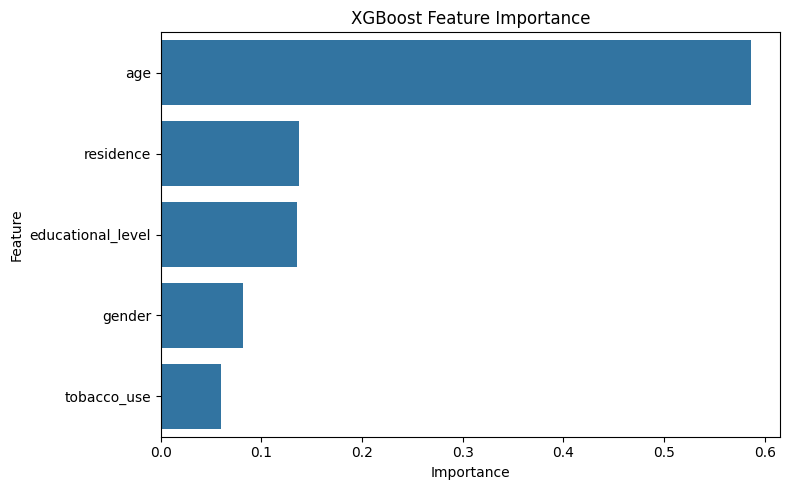

In [200]:
# XGBoost feature importance plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Step 8: XGBoost Hyperparameter Optimization & Model Comparison

**Objective:** Improve the discrimination and screening performance of the baseline XGBoost model.

**Method:** RandomizedSearchCV with 5-fold stratified cross-validation.

**Optimization Metric:** ROC-AUC

**Rationale:** ROC-AUC evaluates the model's ability to rank hypertensive and non-hypertensive individuals independently of any classification threshold. Screening thresholds will be selected separately during deployment-oriented evaluation.

In [201]:
# XGBoost hyperparameter search space

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "gamma": [0, 0.1, 0.5, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "scale_pos_weight": [5, 7.7, 10]
}

In [202]:
# Cross-validation strategy

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [203]:
# Randomized hyperparameter search

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [204]:
# Best hyperparameters

print("Best ROC-AUC:", xgb_search.best_score_)
print()

for param, value in xgb_search.best_params_.items():
    print(f"{param}: {value}")

Best ROC-AUC: 0.7324098823647104

subsample: 0.8
scale_pos_weight: 5
reg_lambda: 10.0
reg_alpha: 0.1
n_estimators: 200
min_child_weight: 1
max_depth: 2
learning_rate: 0.05
gamma: 0
colsample_bytree: 0.6


In [205]:
# Best tuned model

best_xgb = xgb_search.best_estimator_

In [206]:
# Tuned XGBoost predictions

best_xgb_pred = best_xgb.predict(X_test)
best_xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

In [207]:
# Baseline vs tuned comparison

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "ROC_AUC": [
        0.7322,
        0.6782,
        0.7283,
        roc_auc_score(y_test, best_xgb_prob)
    ]
})

comparison_df.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
3,Tuned XGBoost,0.735396
0,Logistic Regression,0.732200
2,Baseline XGBoost,0.728300
1,Random Forest,0.678200


In [208]:
evaluate_model(
    model_name="Tuned XGBoost",
    y_true=y_test,
    y_pred=best_xgb_pred,
    y_prob=best_xgb_prob
)

TUNED XGBOOST
Accuracy : 0.7496
Precision: 0.2397
Recall   : 0.5426
F1 Score : 0.3325
ROC-AUC  : 0.7354
Brier    : 0.1623

Confusion Matrix
[[2811  809]
 [ 215  255]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      3620
           1       0.24      0.54      0.33       470

    accuracy                           0.75      4090
   macro avg       0.58      0.66      0.59      4090
weighted avg       0.85      0.75      0.79      4090



In [209]:
# Threshold optimization

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_xgb_prob
)

target_recall = 0.80

best_idx = np.argmin(
    np.abs(tpr - target_recall)
)

xgb_threshold = thresholds[best_idx]

print(f"Threshold: {xgb_threshold:.3f}")
print(f"Recall: {tpr[best_idx]:.3f}")
print(f"Specificity: {1-fpr[best_idx]:.3f}")

Threshold: 0.353
Recall: 0.800
Specificity: 0.542


In [210]:
xgb_screen_pred = (
    best_xgb_prob >= xgb_threshold
).astype(int)

evaluate_model(
    model_name="Tuned XGBoost (Screening)",
    y_true=y_test,
    y_pred=xgb_screen_pred,
    y_prob=best_xgb_prob
)

TUNED XGBOOST (SCREENING)
Accuracy : 0.5714
Precision: 0.1848
Recall   : 0.8000
F1 Score : 0.3002
ROC-AUC  : 0.7354
Brier    : 0.1623

Confusion Matrix
[[1961 1659]
 [  94  376]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.54      0.69      3620
           1       0.18      0.80      0.30       470

    accuracy                           0.57      4090
   macro avg       0.57      0.67      0.50      4090
weighted avg       0.87      0.57      0.65      4090





#### STEP 9: Calibration Assessment (Deferred)
Calibration was explored as a potential post-modelling enhancement to improve probability estimates produced by the final XGBoost model. Given the current timeline and considering that I forgot to create a calibration holdout set in the current modelling pipeline, formal probability calibration shall be deferred. Future work will evaluate isotonic regression and Platt scaling using a separate calibration dataset and assess improvements using calibration curves and Brier scores.

In [213]:
# save final model

joblib.dump(
    best_xgb,
    "../models/hypersense_xgb.pkl"
)

['../models/hypersense_xgb.pkl']

### Modelling Conclusion

Among the evaluated models, tuned XGBoost demonstrated the best overall discrimination performance (ROC-AUC = 0.735) while maintaining high sensitivity (Recall = 0.80) at the selected screening threshold.

Given the intended use of HyperSense as a hypertension screening tool, the tuned XGBoost model was selected as the final deployment model.

Formal probability calibration was not performed due to the absence of a dedicated calibration holdout set in the current pipeline. This is identified as a future methodological enhancement.